<a href="https://colab.research.google.com/github/jesusessu/MDD_LAB12/blob/develop/MDD_LAB12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SEMANA 12: DISTRIBUCIONES DE PROBABILIDAD A PRIORI Y POSTERIORI**

Alumno: Esplana Sulla Jesús Zósimo

In [1]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 1.9 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

!pip install category-encoders
!pip install imbalanced-learn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Paso 1: Cargar los datos desde tu ruta local

In [4]:
import pandas as pd

file_path = '/content/drive/MyDrive/TECSUP/Ciclo 5/Mineria de Datos/obesidad.csv'
df = pd.read_csv(file_path)

# Información básica
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   int64  
 7   NCP                             2111 non-null   int64  
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   int64  
 11  SCC                             2111 non-null   object 
 12  FAF                             21

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


Paso 2: Análisis de datos faltantes

In [5]:
# Comprobación de nulos
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


Paso 3: Tratamiento de outliers

**Univariado**

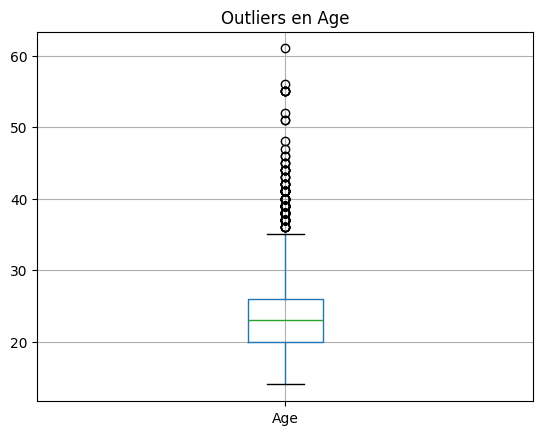

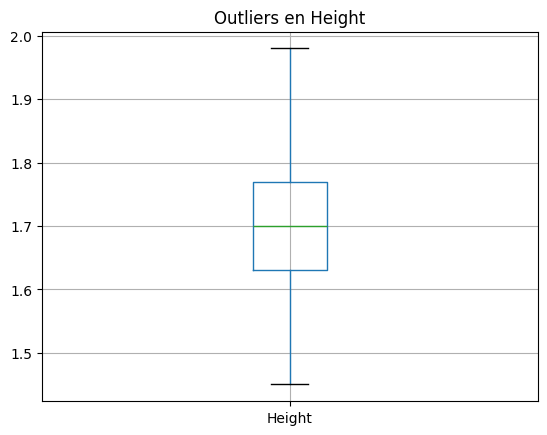

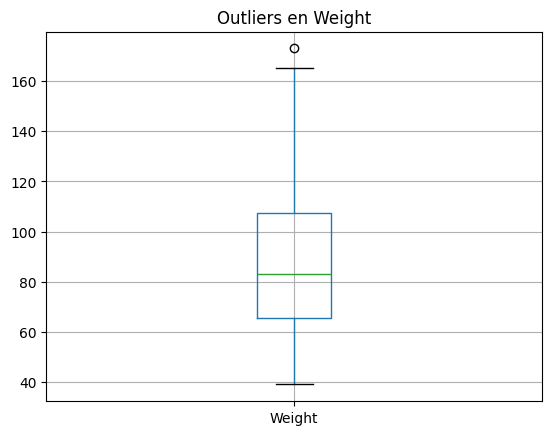

In [6]:
import matplotlib.pyplot as plt

for col in ['Age', 'Height', 'Weight']:
    plt.figure()
    df.boxplot([col])
    plt.title(f"Outliers en {col}")

**Multivariado**

In [7]:
from sklearn.covariance import EllipticEnvelope
import numpy as np

ee = EllipticEnvelope(contamination=0.01)
filtered = ee.fit_predict(df[['Age', 'Height', 'Weight']])
df = df[filtered == 1]

Paso 4: Balanceo de clases

In [8]:
from imblearn.over_sampling import SMOTE

X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# Encoding previo para SMOTE
X_temp = pd.get_dummies(X)
sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X_temp, y)

Paso 5: OneHotEncoder con category_encoders

In [9]:
import category_encoders as ce

encoder = ce.OneHotEncoder(use_cat_names=True)
X_encoded = encoder.fit_transform(X)

Paso 6: Separar y entrenar modelos Naive Bayes

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
acc_gnb = accuracy_score(y_test, gnb.predict(X_test))

# MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
acc_mnb = accuracy_score(y_test, mnb.predict(X_test))

Paso 7: Resultados

In [11]:
print(f"Accuracy GaussianNB: {acc_gnb:.4f}")
print(f"Accuracy MultinomialNB: {acc_mnb:.4f}")

Accuracy GaussianNB: 0.5670
Accuracy MultinomialNB: 0.5909
